In [2]:
!pip install -q lightkurve astropy numpy matplotlib scipy

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 52.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.3.0 which is incompatible.
datasets 4.0.0 r

In [3]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [4]:
search_result = lk.search_lightcurve("WASP-18", mission="TESS")
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 02,2018,SPOC,120,100100827,0.0
1,TESS Sector 03,2018,SPOC,120,100100827,0.0
2,TESS Sector 30,2020,SPOC,20,100100827,0.0
3,TESS Sector 29,2020,SPOC,20,100100827,0.0
4,TESS Sector 30,2020,SPOC,120,100100827,0.0
5,TESS Sector 29,2020,SPOC,120,100100827,0.0
6,TESS Sector 69,2023,SPOC,20,100100827,0.0
7,TESS Sector 69,2023,SPOC,120,100100827,0.0
8,TESS Sector 96,2025,SPOC,20,100100827,0.0


In [5]:
lc = search_result.download()
lc

/usr/local/lib/python3.12/dist-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 35 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1354.1115072617192,4.7745688e+04,2.5922741e+01,3.2845002e-03,91190,1638.57401,468.04924,4.5699730e+04,2.4585836e+01,2.1270193e+03,7.5499601e+00,4.7745688e+04,2.5922741e+01,0,———,———,———,———,1638.57401,5.5316015e-04,468.04924,5.7710981e-04,-1.2000147e-01,7.8144908e-02
1354.1128961919705,4.7782176e+04,2.5922379e+01,3.2845421e-03,91191,1638.58778,468.04160,4.5753094e+04,2.4585493e+01,2.1165220e+03,7.5075278e+00,4.7782176e+04,2.5922379e+01,0,———,———,———,———,1638.58778,5.5368309e-04,468.04160,5.7716778e-04,-1.0294508e-01,6.7404680e-02
1354.1142851224547,4.7737035e+04,2.5922800e+01,3.2845843e-03,91192,1638.58725,468.03821,4.5719250e+04,2.4585894e+01,2.1220544e+03,7.5287137e+00,4.7737035e+04,2.5922800e+01,0,———,———,———,———,1638.58725,5.5385107e-04,468.03821,5.7766296e-04,-1.0323820e-01,6.3302755e-02
1354.117062983188,4.7739652e+04,2.5921152e+01,3.2846683e-03,91194,1638.58337,468.02563,4.5696863e+04,2.4584332e+01,2.1406106e+03,7.5460734e+00,4.7739652e+04,2.5921152e+01,0,———,———,———,———,1638.58337,5.5345549e-04,468.02563,5.7999988e-04,-1.0774896e-01,5.0843615e-02
1354.1184519134392,4.7759828e+04,2.5928436e+01,3.2847102e-03,91195,1638.59648,468.05560,4.5737141e+04,2.4591240e+01,2.1321707e+03,7.5400863e+00,4.7759828e+04,2.5928436e+01,0,———,———,———,———,1638.59648,5.5386929e-04,468.05560,5.7663023e-04,-9.3161479e-02,8.3432972e-02
1354.1198408439234,4.7727695e+04,2.5917774e+01,3.2847524e-03,91196,1638.59691,468.04240,4.5714668e+04,2.4581129e+01,2.1199805e+03,7.5265331e+00,4.7727695e+04,2.5917774e+01,0,———,———,———,———,1638.59691,5.5403763e-04,468.04240,5.7726464e-04,-9.2094876e-02,6.8144821e-02
1354.1212297741743,4.7743820e+04,2.5920904e+01,3.2847943e-03,91197,1638.59657,468.04020,4.5730688e+04,2.4584095e+01,2.1182432e+03,7.5189238e+00,4.7743820e+04,2.5920904e+01,0,———,———,———,———,1638.59657,5.5452809e-04,468.04020,5.7684036e-04,-9.1556683e-02,6.7030065e-02
1354.1226187044247,4.7756164e+04,2.5933273e+01,3.2848362e-03,91198,1638.59394,468.03319,4.5747023e+04,2.4595827e+01,2.1307397e+03,7.5524945e+00,4.7756164e+04,2.5933273e+01,0,———,———,———,———,1638.59394,5.5433990e-04,468.03319,5.7723687e-04,-9.4503127e-02,5.9139974e-02


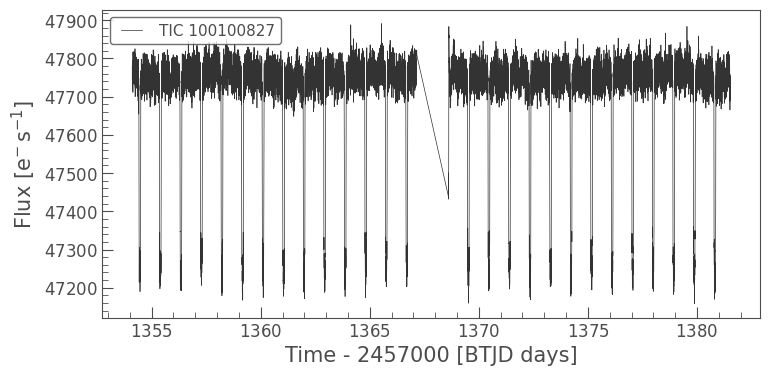

In [6]:
lc.plot()
plt.show()

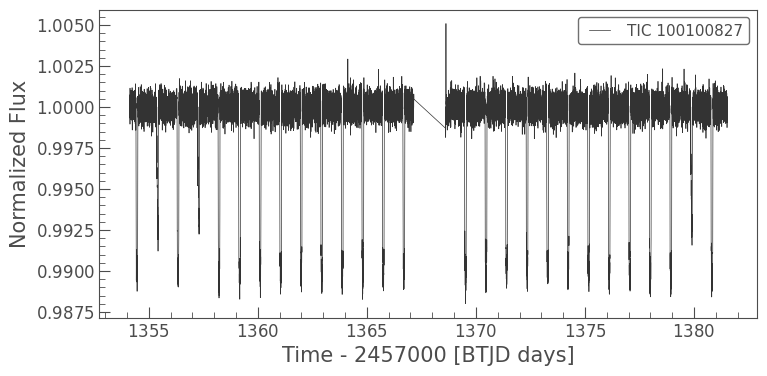

In [7]:
lc_clean = lc.remove_outliers().flatten()
lc_clean.plot()
plt.show()

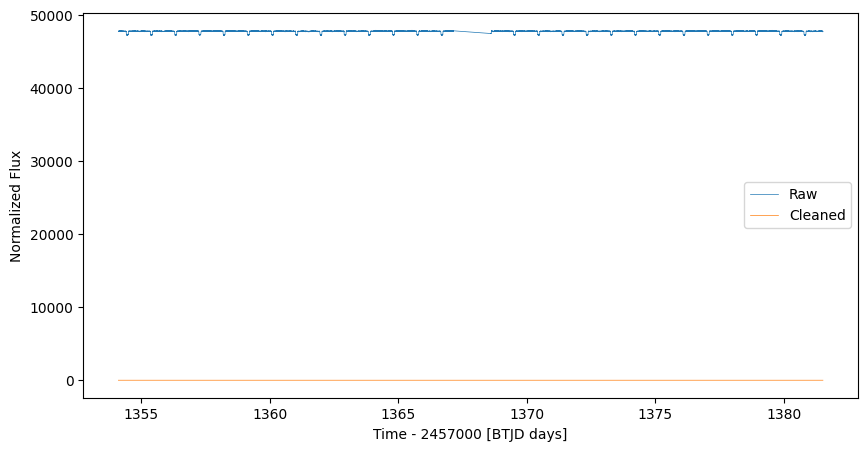

In [8]:
fig, ax = plt.subplots(figsize=(10,5))

lc.plot(ax=ax, label="Raw")
lc_clean.plot(ax=ax, label="Cleaned")

plt.legend()
plt.show()

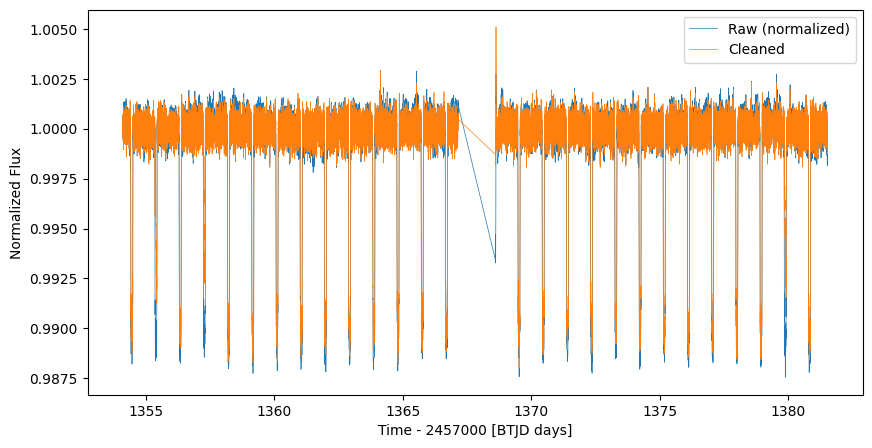

In [9]:
fig, ax = plt.subplots(figsize=(10,5))

lc.normalize().plot(ax=ax, label="Raw (normalized)")
lc_clean.plot(ax=ax, label="Cleaned")

plt.legend()
plt.show()

In [10]:
lc_clean


time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,,,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float64,float64,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1354.1115072617192,9.9998477e-01,5.4292539e-04,3.2845002e-03,91190,1638.57401,468.04924,4.5699730e+04,2.4585836e+01,2.1270193e+03,7.5499601e+00,4.7745688e+04,2.5922741e+01,0,———,———,———,———,1638.57401,5.5316015e-04,468.04924,5.7710981e-04,-1.2000147e-01,7.8144908e-02
1354.1128961919705,1.0007303e+00,5.4290768e-04,3.2845421e-03,91191,1638.58778,468.04160,4.5753094e+04,2.4585493e+01,2.1165220e+03,7.5075278e+00,4.7782176e+04,2.5922379e+01,0,———,———,———,———,1638.58778,5.5368309e-04,468.04160,5.7716778e-04,-1.0294508e-01,6.7404680e-02
1354.1142851224547,9.9976659e-01,5.4290656e-04,3.2845843e-03,91192,1638.58725,468.03821,4.5719250e+04,2.4585894e+01,2.1220544e+03,7.5287137e+00,4.7737035e+04,2.5922800e+01,0,———,———,———,———,1638.58725,5.5385107e-04,468.03821,5.7766296e-04,-1.0323820e-01,6.3302755e-02
1354.117062983188,9.9980340e-01,5.4286227e-04,3.2846683e-03,91194,1638.58337,468.02563,4.5696863e+04,2.4584332e+01,2.1406106e+03,7.5460734e+00,4.7739652e+04,2.5921152e+01,0,———,———,———,———,1638.58337,5.5345549e-04,468.02563,5.7999988e-04,-1.0774896e-01,5.0843615e-02
1354.1184519134392,1.0002083e+00,5.4300522e-04,3.2847102e-03,91195,1638.59648,468.05560,4.5737141e+04,2.4591240e+01,2.1321707e+03,7.5400863e+00,4.7759828e+04,2.5928436e+01,0,———,———,———,———,1638.59648,5.5386929e-04,468.05560,5.7663023e-04,-9.3161479e-02,8.3432972e-02
1354.1198408439234,9.9951797e-01,5.4277251e-04,3.2847524e-03,91196,1638.59691,468.04240,4.5714668e+04,2.4581129e+01,2.1199805e+03,7.5265331e+00,4.7727695e+04,2.5917774e+01,0,———,———,———,———,1638.59691,5.5403763e-04,468.04240,5.7726464e-04,-9.2094876e-02,6.8144821e-02
1354.1212297741743,9.9983862e-01,5.4282881e-04,3.2847943e-03,91197,1638.59657,468.04020,4.5730688e+04,2.4584095e+01,2.1182432e+03,7.5189238e+00,4.7743820e+04,2.5920904e+01,0,———,———,———,———,1638.59657,5.5452809e-04,468.04020,5.7684036e-04,-9.1556683e-02,6.7030065e-02
1354.1226187044247,1.0000804e+00,5.4307876e-04,3.2848362e-03,91198,1638.59394,468.03319,4.5747023e+04,2.4595827e+01,2.1307397e+03,7.5524945e+00,4.7756164e+04,2.5933273e+01,0,———,———,———,———,1638.59394,5.5433990e-04,468.03319,5.7723687e-04,-9.4503127e-02,5.9139974e-02


In [11]:
periodogram = lc_clean.to_periodogram(method="bls")
periodogram

BoxLeastSquaresPeriodogram(ID: TIC 100100827)

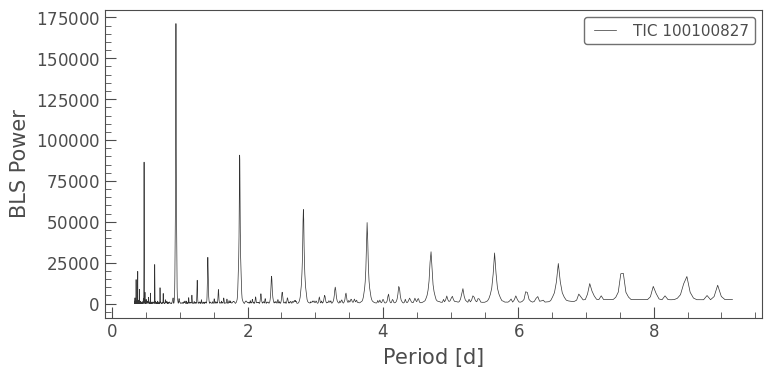

In [12]:
periodogram.plot()
plt.show()

In [13]:
best_period = periodogram.period_at_max_power
best_period

<Quantity 0.94123489 d>

In [14]:
print("Best period:", best_period)

Best period: 0.9412348890273298 d


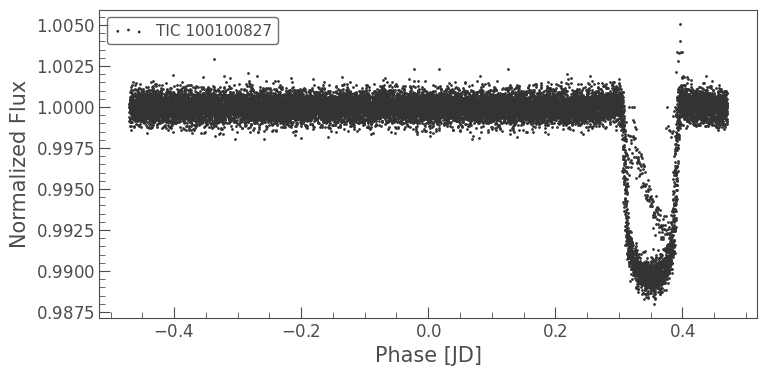

In [15]:
lc_folded = lc_clean.fold(period=best_period)
lc_folded.scatter()
plt.show()

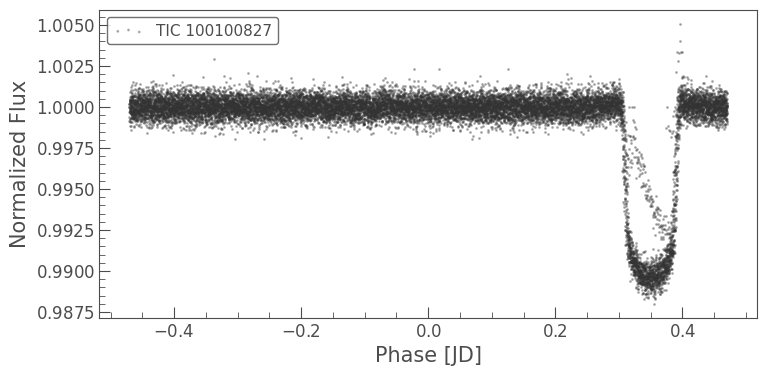

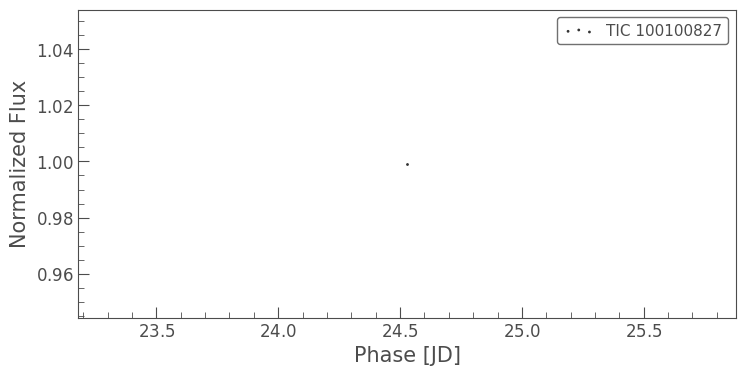

In [16]:
lc_folded_binned = lc_folded.bin(50)
lc_folded.scatter(alpha=0.3, s=5)
lc_folded_binned.scatter()
plt.show()

Inject Stellar Variability into WASP-18

In [18]:
time = lc_clean.time.value
flux = lc_clean.flux.value

In [19]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

search_result = lk.search_lightcurve("WASP-18", mission="TESS")
lc = search_result.download()
lc_clean = lc.remove_outliers().flatten()

time = lc_clean.time.value
flux = lc_clean.flux.value

/usr/local/lib/python3.12/dist-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 35 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


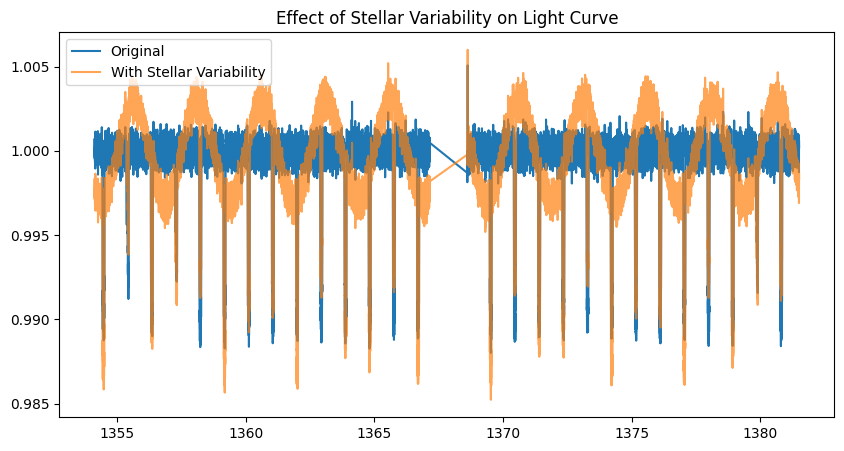

In [20]:
variability = 0.003 * np.sin(2 * np.pi * time / 2.5)

flux_with_variability = flux + variability

plt.figure(figsize=(10,5))
plt.plot(time, flux, label="Original")
plt.plot(time, flux_with_variability, label="With Stellar Variability", alpha=0.7)
plt.legend()
plt.title("Effect of Stellar Variability on Light Curve")
plt.show()

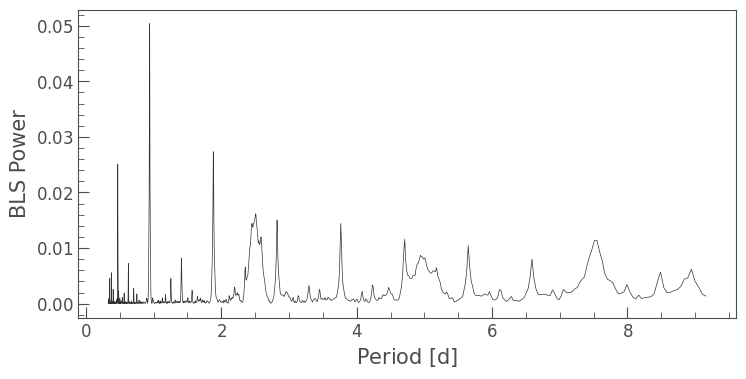

In [21]:
lc_var = lk.LightCurve(time=time, flux=flux_with_variability)

periodogram_var = lc_var.to_periodogram(method="bls")
periodogram_var.plot()
plt.show()

In [22]:
best_period_var = periodogram_var.period_at_max_power
print("Detected period with variability:", best_period_var)

Detected period with variability: 0.9412348890273298 d


<Figure size 1000x500 with 0 Axes>

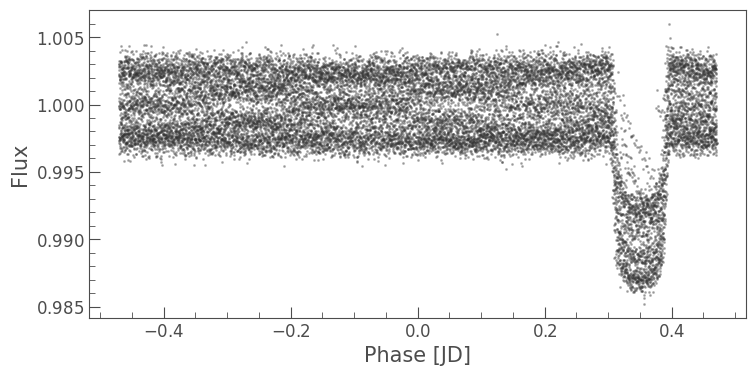

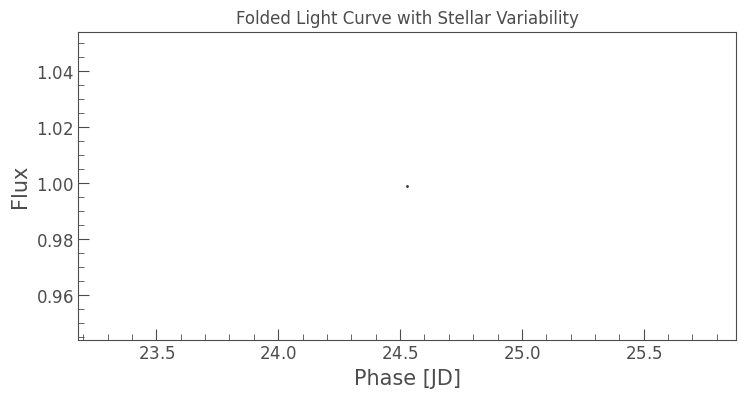

In [23]:
lc_folded_var = lc_var.fold(period=best_period_var)

plt.figure(figsize=(10,5))
lc_folded_var.scatter(alpha=0.3, s=5)
lc_folded_var.bin(50).scatter()
plt.title("Folded Light Curve with Stellar Variability")
plt.show()

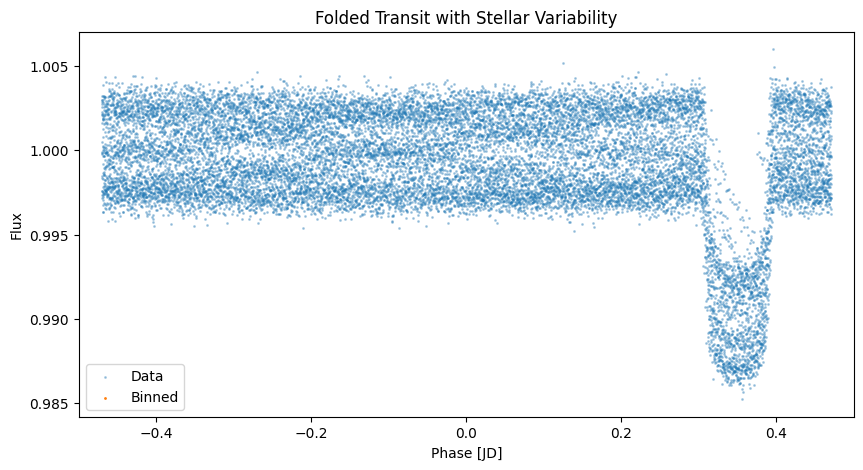

In [24]:
fig, ax = plt.subplots(figsize=(10,5))

lc_folded_var.scatter(ax=ax, alpha=0.3, s=5, label="Data")
lc_folded_var.bin(50).scatter(ax=ax, label="Binned")

ax.set_xlim(-0.5, 0.5)
ax.set_title("Folded Transit with Stellar Variability")
plt.legend()
plt.show()

In [25]:
variability_strong = 0.01 * np.sin(2 * np.pi * time / 2.5)

flux_strong = flux + variability_strong

lc_strong = lk.LightCurve(time=time, flux=flux_strong)

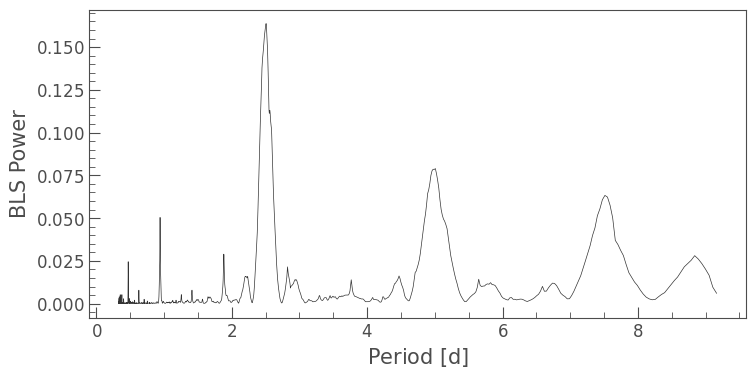

Strong variability period: 2.507971577413153 d


In [26]:
periodogram_strong = lc_strong.to_periodogram(method="bls")
periodogram_strong.plot()
plt.show()

best_period_strong = periodogram_strong.period_at_max_power
print("Strong variability period:", best_period_strong)

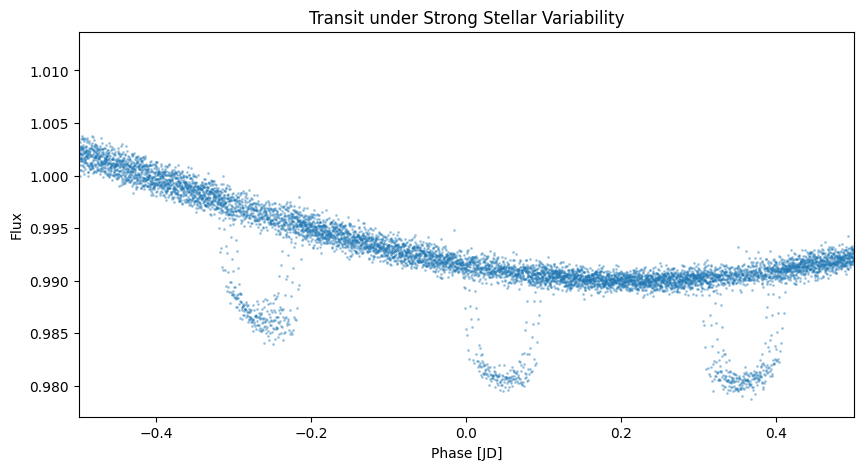

In [27]:
lc_folded_strong = lc_strong.fold(period=best_period_strong)

fig, ax = plt.subplots(figsize=(10,5))
lc_folded_strong.scatter(ax=ax, alpha=0.3, s=5)
lc_folded_strong.bin(50).scatter(ax=ax)

ax.set_xlim(-0.5, 0.5)
ax.set_title("Transit under Strong Stellar Variability")
plt.show()

Transit Recovery in the Active AU Mic System Using TESS Light Curves


In [28]:
!pip install -q lightkurve astropy numpy matplotlib scipy

In [29]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

In [30]:
search_result_au = lk.search_lightcurve("AU Mic", mission="TESS")
search_result_au

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 01,2018,SPOC,120,441420236,0.0
1,TESS Sector 27,2020,SPOC,20,441420236,0.0
2,TESS Sector 27,2020,SPOC,120,441420236,0.0
3,TESS Sector 95,2025,SPOC,20,441420236,0.0
4,TESS Sector 95,2025,SPOC,120,441420236,0.0
5,TESS Sector 01,2018,TESS-SPOC,1800,441420236,0.0
6,TESS Sector 27,2020,TESS-SPOC,600,441420236,0.0
7,TESS Sector 01,2018,QLP,1800,441420236,0.0
8,TESS Sector 27,2020,QLP,600,441420236,0.0


In [31]:
lc_au = search_result_au.download()
lc_au

/usr/local/lib/python3.12/dist-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 15 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1325.9014014149052,———,———,5.6842496e-03,70877,1757.69617,1244.45279,2.7356894e+05,5.6835831e+01,5.2545107e+03,9.6808643e+00,———,———,1000000000000,———,———,———,———,1757.69617,1.9775577e-04,1244.45279,1.9123718e-04,-4.1962471e-02,1.2484190e-01
1325.9027903018405,———,———,5.6842482e-03,70878,1757.69553,1244.45197,2.7353606e+05,5.6832882e+01,5.2688345e+03,9.6850615e+00,———,———,1000000000000,———,———,———,———,1757.69553,1.9776366e-04,1244.45197,1.9126573e-04,-4.5910392e-02,1.2191717e-01
1325.9041791892405,———,———,5.6842472e-03,70879,1757.69173,1244.45514,2.7356834e+05,5.6836292e+01,5.2604854e+03,9.6766872e+00,———,———,1000000000000,———,———,———,———,1757.69173,1.9771728e-04,1244.45514,1.9118906e-04,-5.3685054e-02,1.2677807e-01
1325.9055680761744,———,———,5.6842458e-03,70880,1757.69083,1244.44525,2.7353700e+05,5.6829182e+01,5.2567700e+03,9.6680765e+00,———,———,1000000000000,———,———,———,———,1757.69083,1.9771342e-04,1244.44525,1.9135514e-04,-4.3270692e-02,1.1676704e-01
1325.9069569631097,———,———,5.6842444e-03,70881,1757.69713,1244.46130,2.7357888e+05,5.6827137e+01,5.2592607e+03,9.6619081e+00,———,———,1000000000000,———,———,———,———,1757.69713,1.9773976e-04,1244.46130,1.9107840e-04,-4.5690022e-02,1.3290404e-01
1325.908345850044,———,———,5.6842430e-03,70882,1757.70068,1244.45085,2.7369009e+05,5.6842590e+01,5.2790044e+03,9.6648235e+00,———,———,1000000000000,———,———,———,———,1757.70068,1.9769077e-04,1244.45085,1.9119332e-04,-4.2280581e-02,1.2706219e-01
1325.9097347374436,———,———,5.6842421e-03,70883,1757.69170,1244.46123,2.7360481e+05,5.6834797e+01,5.2554214e+03,9.6744242e+00,———,———,1000000000000,———,———,———,———,1757.69170,1.9773129e-04,1244.46123,1.9112547e-04,-5.9647217e-02,1.3545100e-01
1325.911123624379,———,———,5.6842407e-03,70884,1757.69206,1244.45697,2.7359581e+05,5.6829468e+01,5.2474727e+03,9.6551218e+00,———,———,1000000000000,———,———,———,———,1757.69206,1.9767036e-04,1244.45697,1.9121054e-04,-5.1075567e-02,1.3069212e-01


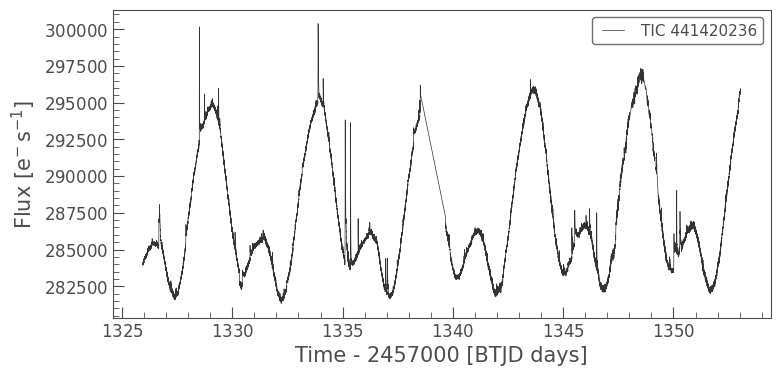

In [32]:
lc_au.plot()
plt.show()

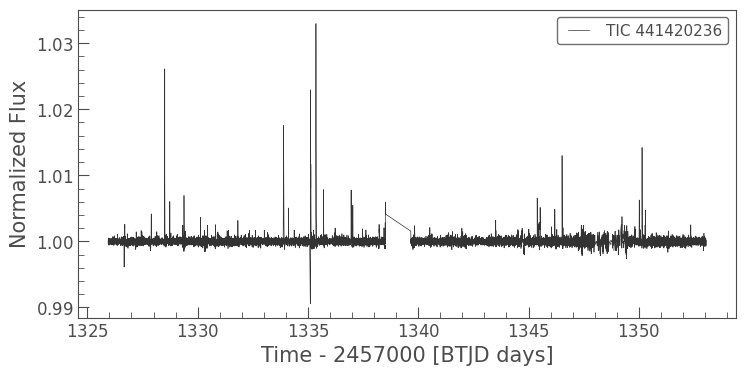

In [33]:
lc_au_clean = lc_au.remove_outliers().flatten()
lc_au_clean.plot()
plt.show()

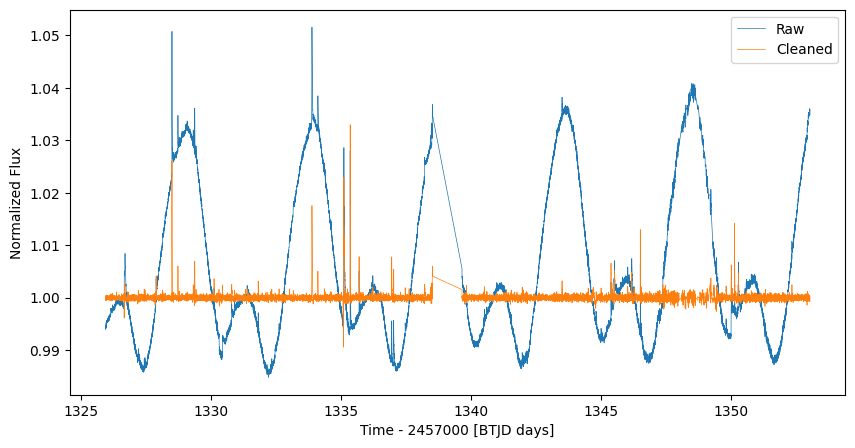

In [34]:
fig, ax = plt.subplots(figsize=(10,5))
lc_au.normalize().plot(ax=ax, label="Raw")
lc_au_clean.plot(ax=ax, label="Cleaned")
plt.legend()
plt.show()

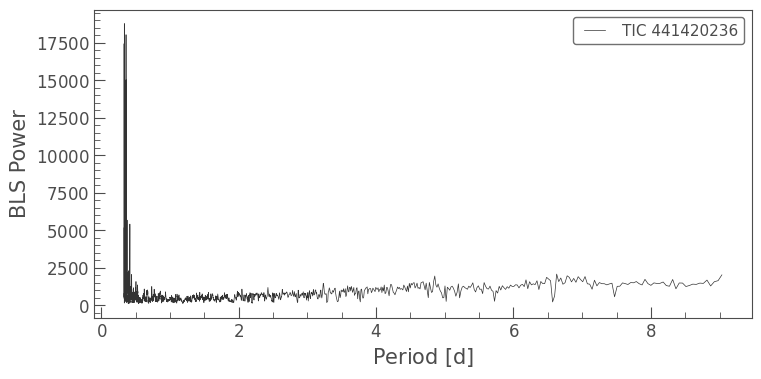

In [35]:
periodogram_au = lc_au_clean.to_periodogram(method="bls")
periodogram_au.plot()
plt.show()

In [36]:
best_period_au = periodogram_au.period_at_max_power
print("Detected AU Mic period:", best_period_au)

Detected AU Mic period: 0.3353991920984211 d


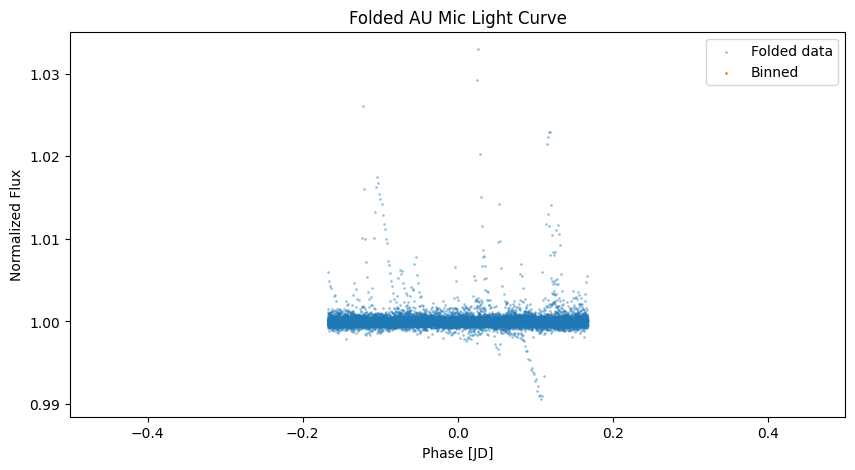

In [37]:
lc_au_folded = lc_au_clean.fold(period=best_period_au)

fig, ax = plt.subplots(figsize=(10,5))
lc_au_folded.scatter(ax=ax, alpha=0.3, s=5, label="Folded data")
lc_au_folded.bin(50).scatter(ax=ax, label="Binned")
ax.set_xlim(-0.5, 0.5)
ax.set_title("Folded AU Mic Light Curve")
plt.legend()
plt.show()

In [38]:
search_result_au = lk.search_lightcurve("AU Mic", mission="TESS")
search_result_au

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 01,2018,SPOC,120,441420236,0.0
1,TESS Sector 27,2020,SPOC,20,441420236,0.0
2,TESS Sector 27,2020,SPOC,120,441420236,0.0
3,TESS Sector 95,2025,SPOC,20,441420236,0.0
4,TESS Sector 95,2025,SPOC,120,441420236,0.0
5,TESS Sector 01,2018,TESS-SPOC,1800,441420236,0.0
6,TESS Sector 27,2020,TESS-SPOC,600,441420236,0.0
7,TESS Sector 01,2018,QLP,1800,441420236,0.0
8,TESS Sector 27,2020,QLP,600,441420236,0.0


In [39]:
lc_au = search_result_au.download()
lc_au

/usr/local/lib/python3.12/dist-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 15 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1325.9014014149052,———,———,5.6842496e-03,70877,1757.69617,1244.45279,2.7356894e+05,5.6835831e+01,5.2545107e+03,9.6808643e+00,———,———,1000000000000,———,———,———,———,1757.69617,1.9775577e-04,1244.45279,1.9123718e-04,-4.1962471e-02,1.2484190e-01
1325.9027903018405,———,———,5.6842482e-03,70878,1757.69553,1244.45197,2.7353606e+05,5.6832882e+01,5.2688345e+03,9.6850615e+00,———,———,1000000000000,———,———,———,———,1757.69553,1.9776366e-04,1244.45197,1.9126573e-04,-4.5910392e-02,1.2191717e-01
1325.9041791892405,———,———,5.6842472e-03,70879,1757.69173,1244.45514,2.7356834e+05,5.6836292e+01,5.2604854e+03,9.6766872e+00,———,———,1000000000000,———,———,———,———,1757.69173,1.9771728e-04,1244.45514,1.9118906e-04,-5.3685054e-02,1.2677807e-01
1325.9055680761744,———,———,5.6842458e-03,70880,1757.69083,1244.44525,2.7353700e+05,5.6829182e+01,5.2567700e+03,9.6680765e+00,———,———,1000000000000,———,———,———,———,1757.69083,1.9771342e-04,1244.44525,1.9135514e-04,-4.3270692e-02,1.1676704e-01
1325.9069569631097,———,———,5.6842444e-03,70881,1757.69713,1244.46130,2.7357888e+05,5.6827137e+01,5.2592607e+03,9.6619081e+00,———,———,1000000000000,———,———,———,———,1757.69713,1.9773976e-04,1244.46130,1.9107840e-04,-4.5690022e-02,1.3290404e-01
1325.908345850044,———,———,5.6842430e-03,70882,1757.70068,1244.45085,2.7369009e+05,5.6842590e+01,5.2790044e+03,9.6648235e+00,———,———,1000000000000,———,———,———,———,1757.70068,1.9769077e-04,1244.45085,1.9119332e-04,-4.2280581e-02,1.2706219e-01
1325.9097347374436,———,———,5.6842421e-03,70883,1757.69170,1244.46123,2.7360481e+05,5.6834797e+01,5.2554214e+03,9.6744242e+00,———,———,1000000000000,———,———,———,———,1757.69170,1.9773129e-04,1244.46123,1.9112547e-04,-5.9647217e-02,1.3545100e-01
1325.911123624379,———,———,5.6842407e-03,70884,1757.69206,1244.45697,2.7359581e+05,5.6829468e+01,5.2474727e+03,9.6551218e+00,———,———,1000000000000,———,———,———,———,1757.69206,1.9767036e-04,1244.45697,1.9121054e-04,-5.1075567e-02,1.3069212e-01


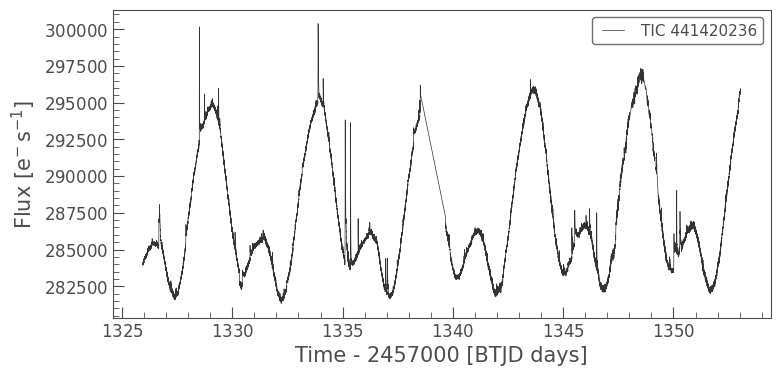

In [40]:
lc_au.plot()
plt.show()

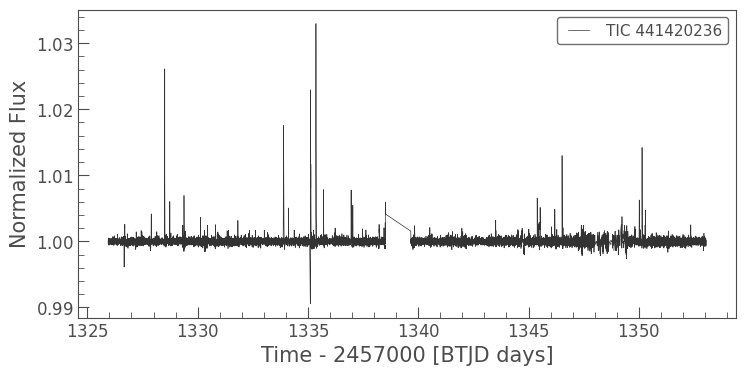

In [41]:
lc_au_clean = lc_au.remove_outliers().flatten()
lc_au_clean.plot()
plt.show()

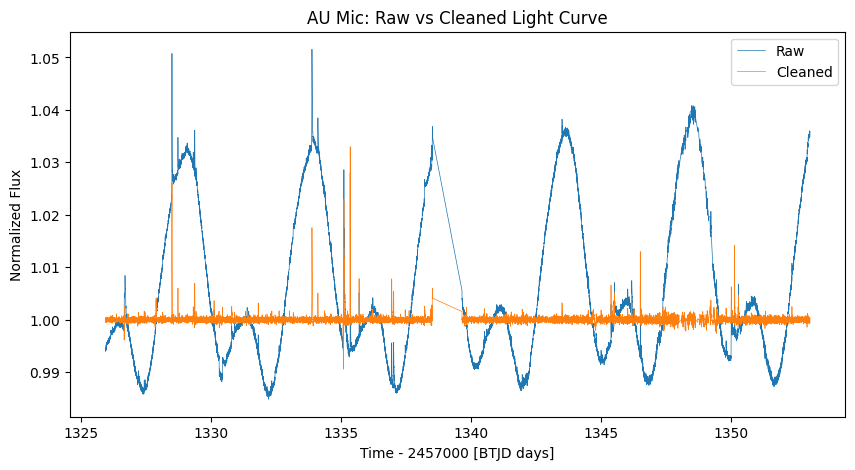

In [42]:
fig, ax = plt.subplots(figsize=(10,5))

lc_au.normalize().plot(ax=ax, label="Raw")
lc_au_clean.plot(ax=ax, label="Cleaned")

plt.legend()
plt.title("AU Mic: Raw vs Cleaned Light Curve")
plt.show()

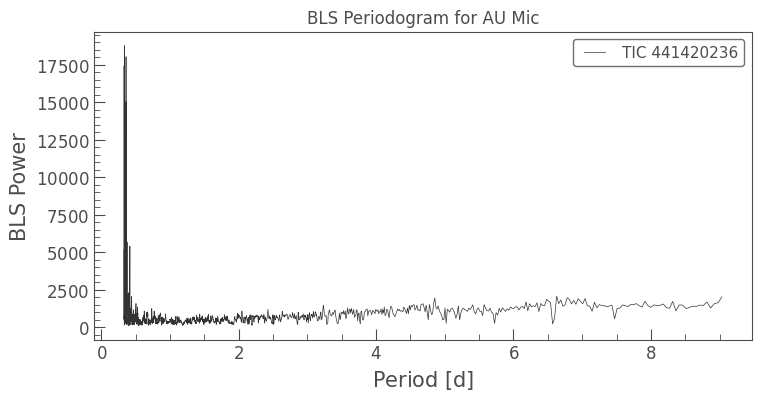

In [43]:
periodogram_au = lc_au_clean.to_periodogram(method="bls")

periodogram_au.plot()
plt.title("BLS Periodogram for AU Mic")
plt.show()

In [44]:
best_period_au = periodogram_au.period_at_max_power
print("Detected period:", best_period_au)

Detected period: 0.3353991920984211 d


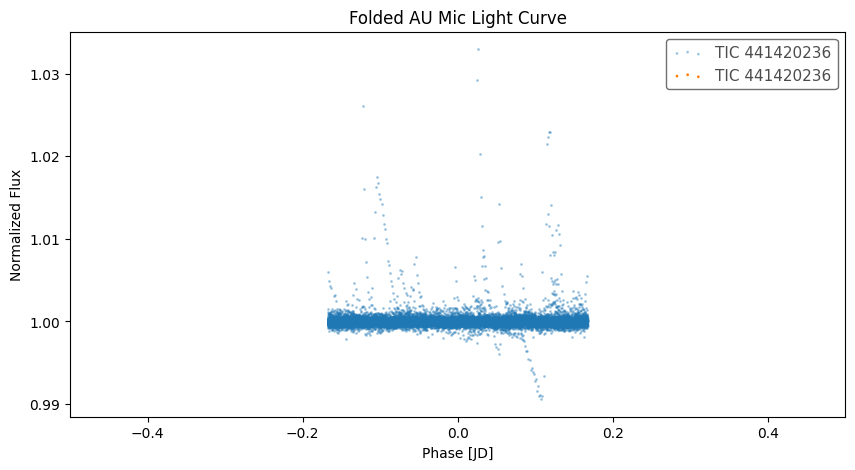

In [45]:
lc_au_folded = lc_au_clean.fold(period=best_period_au)

fig, ax = plt.subplots(figsize=(10,5))

lc_au_folded.scatter(ax=ax, alpha=0.3, s=5)
lc_au_folded.bin(50).scatter(ax=ax)

ax.set_xlim(-0.5, 0.5)
ax.set_title("Folded AU Mic Light Curve")
plt.show()